# Optimization and resampling

Executable companion to chapter 14.

Chapter 13 left two loose ends: the variational parameters were found by
scanning a grid, and the error bar came from the autocorrelation time.  Both
are fixed here, in the three stages a real calculation has:

1. **Optimise** — the gradient of the energy is another Monte Carlo average,
   so it costs nothing extra.  Short, noisy runs are enough while we are
   locating a minimum.
2. **Produce** — with the parameters fixed, run once with millions of samples.
3. **Resample** — the samples are correlated, so $\sigma/\sqrt N$ is wrong.
   Blocking, bootstrap or jackknife give the honest error.

In [1]:
import sys
sys.path.insert(0, "../BookManybody/BookMaterial/Programs")

import math
import numpy as np
import matplotlib.pyplot as plt

import vmcoptimise as vo
from vmc import TAUT_ENERGY, correlation_time

## 1. The gradient of the energy

$$
\bar E_\theta = 2\left(\left\langle \frac{\bar\psi_\theta}{\psi} E_L\right\rangle
- \left\langle \frac{\bar\psi_\theta}{\psi}\right\rangle\langle E_L\rangle\right)
$$

It is a **covariance**: twice the covariance of the local energy with
$O_\theta = \partial\ln\psi/\partial\theta$.  It needs only first derivatives
of $\ln\psi$, no derivatives of $E_L$, and no extra sampling.

In [2]:
rng = np.random.default_rng(3)
worst = 0.0
for _ in range(40):
    r = rng.normal(0.0, 1.0, (2, 2))
    for a, b in ((0.98, 0.40), (0.80, 0.25), (1.10, 0.60)):
        worst = max(worst, float(np.abs(vo.log_psi_gradient(r, a, b)
                                        - vo.log_psi_gradient_fd(r, a, b)).max()))
print(f"d lnPsi/d(alpha,beta), analytic vs finite differences: {worst:.1e}")

d lnPsi/d(alpha,beta), analytic vs finite differences: 1.7e-09


In [3]:
print(f"{'alpha':>6s} {'beta':>6s} {'dE/da':>19s} {'dE/db':>19s}")
for a, b in ((0.90, 0.30), (1.00, 0.40), (1.05, 0.50)):
    g = vo.sample(a, b, n_cycles=15000, rng=np.random.default_rng(99))["gradient"]
    h, num = 0.01, np.empty(2)
    for k, (da, db) in enumerate(((h, 0.0), (0.0, h))):
        p = vo.sample(a+da, b+db, n_cycles=15000, rng=np.random.default_rng(99))["energy"]
        m = vo.sample(a-da, b-db, n_cycles=15000, rng=np.random.default_rng(99))["energy"]
        num[k] = (p - m)/(2*h)
    print(f"{a:6.2f} {b:6.2f} {g[0]:9.5f} vs {num[0]:7.5f} "
          f"{g[1]:9.5f} vs {num[1]:7.5f}")
print("\nThey agree within the noise — and the analytic route costs one run")
print("instead of four, with no cancellation of nearly equal numbers.")

 alpha   beta               dE/da               dE/db


  0.90   0.30  -0.41045 vs -0.36418  -0.29194 vs -0.24605


  1.00   0.40   0.02894 vs 0.02987   0.01222 vs 0.02174


  1.05   0.50   0.21955 vs 0.21355   0.10397 vs 0.10863

They agree within the noise — and the analytic route costs one run
instead of four, with no cancellation of nearly equal numbers.


## 2. Gradient descent

$\theta \leftarrow \theta - \eta\,\nabla_\theta E$, starting deliberately far
from the minimum.  Note the budget: 6000 cycles per step, far too few to
*report* an energy but ample to decide which way is down.

 iter     alpha      beta       energy      |grad|
    1   0.85000   0.20000     3.109414    1.330032
    2   0.89561   0.24840     3.045335    0.705914
    3   0.92159   0.27229     3.029706    0.507672
    4   0.94097   0.28869     3.015757    0.367980
    5   0.95482   0.30079     3.010026    0.308842
   10   0.99137   0.33306     3.002619    0.098912
   15   1.00313   0.34716     3.001162    0.042637
   20   1.00632   0.35500     3.000192    0.029422

converged to alpha = 1.0067, beta = 0.3564


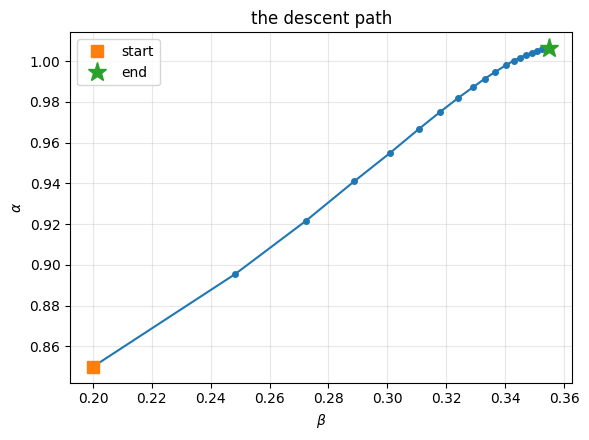

In [4]:
theta, history = vo.gradient_descent(0.85, 0.20, learning_rate=0.05,
                                     max_iter=20, n_cycles=4000)
print(f"{'iter':>5s} {'alpha':>9s} {'beta':>9s} {'energy':>12s} {'|grad|':>11s}")
for it, p, e, g, _ in history:
    if it <= 4 or it % 5 == 0:
        print(f"{it:5d} {p[0]:9.5f} {p[1]:9.5f} {e:12.6f} "
              f"{np.linalg.norm(g):11.6f}")
print(f"\nconverged to alpha = {theta[0]:.4f}, beta = {theta[1]:.4f}")

path = np.array([h[1] for h in history])
plt.figure(figsize=(6, 4.5))
plt.plot(path[:, 1], path[:, 0], "o-", ms=4)
plt.plot(path[0, 1], path[0, 0], "s", ms=9, label="start")
plt.plot(path[-1, 1], path[-1, 0], "*", ms=14, label="end")
plt.xlabel(r"$\beta$"); plt.ylabel(r"$\alpha$")
plt.title("the descent path"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Three optimisers

**Momentum** averages successive gradients — worth as much as the
acceleration when the gradient is noisy.  **Stochastic reconfiguration**
preconditions with the metric of the variational manifold,

$$
S_{kl} = \langle O_k O_l\rangle - \langle O_k\rangle\langle O_l\rangle,
\qquad
\theta \leftarrow \theta - \eta (S+\varepsilon I)^{-1}\nabla_\theta E,
$$

the quantum geometric tensor, so the step does not depend on how the
parameters happen to be scaled.  This is the standard optimiser for
neural-network wave functions.

In [5]:
print(f"{'method':>28s} {'steps':>6s} {'alpha':>9s} {'beta':>9s} {'final E':>12s}")
for name, routine, kw in (
        ("gradient descent", vo.gradient_descent, dict(learning_rate=0.05)),
        ("with momentum", vo.momentum_descent,
         dict(learning_rate=0.03, momentum=0.6)),
        ("stochastic reconfiguration", vo.stochastic_reconfiguration,
         dict(learning_rate=0.2))):
    th, h = routine(0.85, 0.20, max_iter=15, n_cycles=4000, **kw)
    print(f"{name:>28s} {len(h):6d} {th[0]:9.5f} {th[1]:9.5f} {h[-1][2]:12.6f}")
print("\nFor two parameters the choice hardly matters.  The reason to set")
print("them up carefully is what comes later: thousands of parameters, no")
print("grid conceivable, a non-convex surface and a stochastic gradient.")

                      method  steps     alpha      beta      final E


            gradient descent     15   1.00411   0.34905     3.001162


               with momentum     15   1.00817   0.37283     3.000559


  stochastic reconfiguration     15   0.98820   0.39787     3.000394

For two parameters the choice hardly matters.  The reason to set
them up carefully is what comes later: thousands of parameters, no
grid conceivable, a non-convex surface and a stochastic gradient.


## 4. The production run

Nothing left to decide, only statistics to accumulate — and that parallelises
perfectly, since the walkers are independent.

In [6]:
run = vo.production_run(1.00, 0.40, n_walkers=1000, n_steps=2000,
                        time_step=0.5, rng=np.random.default_rng(2024))
series = run["series"]
print(f"{run['n_walkers']} walkers x {run['n_steps']} steps "
      f"= {run['total_samples']:,} local-energy evaluations")
print(f"acceptance {run['acceptance']:.1%}, mean {series.mean():.8f}")
print(f"correlation time of the walker-averaged series "
      f"{correlation_time(series):.2f}")
print("\nAveraging over independent walkers divides the variance and the")
print("autocovariance by the same factor, so tau is unchanged — the error")
print("analysis of chapter 12 is still needed.")

1000 walkers x 2000 steps = 2,000,000 local-energy evaluations
acceptance 87.1%, mean 3.00054858
correlation time of the walker-averaged series 1.27

Averaging over independent walkers divides the variance and the
autocovariance by the same factor, so tau is unchanged — the error
analysis of chapter 12 is still needed.


## 5. Resampling

**Blocking**: average neighbouring pairs repeatedly; the naive error grows
then plateaus, and Jonsson's $\chi^2$ test finds the plateau automatically.
**Bootstrap**: resample *in blocks* — resampling single points destroys the
correlations and reproduces the naive error.  **Jackknife**: leave one block
out at a time; exact for the mean, and its value is for non-linear estimators.

In [7]:
def report(x, label):
    naive = x.std(ddof=1)/math.sqrt(len(x))
    tau = correlation_time(x)
    _, eb, k = vo.blocking(x)
    _, ebo, bb = vo.bootstrap(x, n_resamples=1000, rng=np.random.default_rng(7))
    _, ej, bj = vo.jackknife(x)
    print(f"{label}")
    print(f"   correlation time tau        {tau:8.2f}")
    print(f"   naive sigma/sqrt(N)         {naive:.8f}")
    print(f"   sqrt(tau) x naive           {naive*math.sqrt(tau):.8f}")
    print(f"   blocking                    {eb:.8f}  ({k} transformations)")
    print(f"   bootstrap, blocks of {bb:<4d}   {ebo:.8f}")
    print(f"   jackknife, blocks of {bj:<4d}   {ej:.8f}")
    print(f"   resampled / naive           {eb/naive:8.2f}")
    return eb

error = report(series, "well tuned, time step 0.5:")
print()
bad = vo.production_run(1.00, 0.40, n_walkers=300, n_steps=3000,
                        time_step=0.02, rng=np.random.default_rng(2024))
report(bad["series"], "badly tuned, time step 0.02:")
print()
print("With good sampling the naive estimate is only modestly wrong — but")
print("there is no way to know that without measuring.  With bad sampling it")
print("is wrong by a factor of four, silently.")

well tuned, time step 0.5:
   correlation time tau            1.27
   naive sigma/sqrt(N)         0.00003276
   sqrt(tau) x naive           0.00003690
   blocking                    0.00004858  (1 transformations)
   bootstrap, blocks of 2      0.00003486
   jackknife, blocks of 2      0.00003478
   resampled / naive               1.48



badly tuned, time step 0.02:
   correlation time tau           16.04
   naive sigma/sqrt(N)         0.00004752
   sqrt(tau) x naive           0.00019030
   blocking                    0.00021720  (5 transformations)
   bootstrap, blocks of 32     0.00019338
   jackknife, blocks of 32     0.00018116
   resampled / naive               4.57

With good sampling the naive estimate is only modestly wrong — but
there is no way to know that without measuring.  With bad sampling it
is wrong by a factor of four, silently.


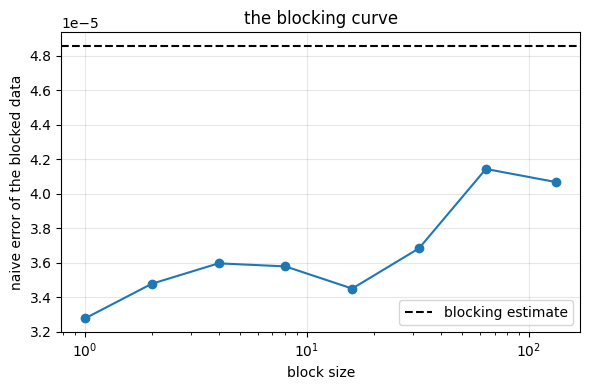

In [8]:
curve = vo.blocking_curve(series)
plt.figure(figsize=(6, 4))
plt.semilogx([len(series)//n for n, _ in curve], [e for _, e in curve], "o-")
plt.axhline(error, ls="--", color="k", label="blocking estimate")
plt.xlabel("block size"); plt.ylabel("naive error of the blocked data")
plt.title("the blocking curve"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. The result

In [9]:
mean = series.mean()
print(f"E = {mean:.6f} +/- {error:.6f}\n")
print(f"{'method':<28s} {'energy':>12s} {'error':>10s}")
for label, value in (("Hartree-Fock, 42 orbitals", 3.161921),
                     ("MP2, 42 orbitals", 3.027038),
                     ("CCSD, 42 orbitals", 3.013626),
                     ("VMC, this chapter", mean),
                     ("exact (Taut)", TAUT_ENERGY)):
    print(f"{label:<28s} {value:12.6f} {abs(value-TAUT_ENERGY):10.1e}")
gap = mean - TAUT_ENERGY
naive = series.std(ddof=1)/math.sqrt(len(series))
print(f"\nThe remaining {gap:.6f} is {gap/error:.0f} standard errors wide, and it")
print("is not statistical — it is what two parameters cannot represent.")
print(f"With the naive error one would have quoted {gap/naive:.0f} standard errors")
print("and concluded, wrongly, that something was broken.")

E = 3.000549 +/- 0.000049

method                             energy      error
Hartree-Fock, 42 orbitals        3.161921    1.6e-01
MP2, 42 orbitals                 3.027038    2.7e-02
CCSD, 42 orbitals                3.013626    1.4e-02
VMC, this chapter                3.000549    5.5e-04
exact (Taut)                     3.000000    0.0e+00

The remaining 0.000549 is 11 standard errors wide, and it
is not statistical — it is what two parameters cannot represent.
With the naive error one would have quoted 17 standard errors
and concluded, wrongly, that something was broken.


## What is left

Every result here is bounded above by what two parameters can express, and no
amount of sampling or optimisation changes that.  Two ways out:

- **Diffusion Monte Carlo** removes the dependence on $\Psi_T$ by projecting
  onto the ground state in imaginary time, using the drift and Green's
  function of chapter 13.
- If the trouble is that we cannot *guess* a good enough functional form, the
  alternative is not to guess: parametrise $\Psi_T$ by a neural network and
  let the gradient and the stochastic-reconfiguration step do the rest.